# Step 1: 라이브러리 & 경로 설정

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('C:/Users/ADMIN/Desktop/AI_FOREST_HEALTH') # ← 본인 환경에 맞게 수정
CSV_DIR   = BASE_DIR / 'data' / 'csv'
PATCH_DIR = BASE_DIR / 'data' / 'patches'
MODEL_DIR = BASE_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ※ 변경 사항 요약
# - MLP 입력: NDVI 제거 → Rain, LST, Elevation 3개만 사용
# - 이유: NDVI는 VCI 계산식의 핵심 재료 → 입력에 넣으면 답을 알려주는 것과 같음
#         NDVI 없이도 기상/지형 데이터만으로 VCI를 추론할 수 있다면
#         고가의 다중분광 센서 없이도 식생 건강도 예측 가능
# - 출력: 3클래스 분류 → VCI 수치 직접 회귀 (0~1 실수 예측)
# - 평가: Accuracy/F1 → MAE, RMSE, R²

Device: cpu


# Step 2: Dataset 클래스 (NDVI 제거, VCI 수치 회귀용)

In [2]:
class VegetationDataset(Dataset):
    NUM_COLS = ['Rain', 'LST', 'Elevation']

    def __init__(self, df, patch_dir, augment=False, mean=None, std=None):
        self.patch_dir = Path(patch_dir)
        self.augment   = augment
        self.records   = []

        for _, row in df.iterrows():
            period = row['period']
            idx    = int(row['idx'])
            patch_path = self.patch_dir / ('patch_' + str(period) + '_' + str(idx).zfill(4) + '.npy')
            if not patch_path.exists():
                continue
            if 'VCI' not in row or pd.isna(row['VCI']):
                continue
            nums = row[self.NUM_COLS].values.astype(np.float32)
            vci  = float(np.clip(row['VCI'], 0.0, 1.0))  # VCI 0~1 클리핑
            self.records.append((patch_path, nums, vci))

        print('유효 샘플 수:', len(self.records))

        all_nums = np.stack([r[1] for r in self.records])
        self.mean = mean if mean is not None else all_nums.mean(0)
        self.std  = std  if std  is not None else all_nums.std(0) + 1e-8
        print('Mean:', self.mean)
        print('Std: ', self.std)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        patch_path, nums, vci = self.records[i]
        patch = np.load(patch_path).astype(np.float32)

        # shape 자동 수정: (H, W, C) → (C, H, W)
        if patch.ndim == 3 and patch.shape[2] == 7:
            patch = patch.transpose(2, 0, 1)
        # 크기 통일: 64x64
        patch = patch[:7, :64, :64]
        if patch.shape[1] < 64 or patch.shape[2] < 64:
            pad = np.zeros((7, 64, 64), dtype=np.float32)
            pad[:, :patch.shape[1], :patch.shape[2]] = patch
            patch = pad

        # 이미지 정규화 (각 밴드 독립)
        for c in range(patch.shape[0]):
            m, s = patch[c].mean(), patch[c].std() + 1e-8
            patch[c] = (patch[c] - m) / s

        # 데이터 증강 (훈련 시)
        if self.augment:
            if np.random.rand() > 0.5:
                patch = patch[:, :, ::-1].copy()
            if np.random.rand() > 0.5:
                patch = patch[:, ::-1, :].copy()
            k = np.random.randint(4)
            patch = np.rot90(patch, k, axes=(1, 2)).copy()

        # 수치 피처 정규화 (mean/std로 표준화)
        nums = (nums - self.mean) / self.std

        return (
            torch.from_numpy(patch),
            torch.from_numpy(nums),
            torch.tensor(vci, dtype=torch.float32)
        )


# CSV 로드
df_all = pd.read_csv(CSV_DIR / 'samples_all.csv')
print('전체 CSV 샘플:', len(df_all))

# VCI 이상값 제거 (0~1 범위 밖 제거)
before = len(df_all)
df_all = df_all[(df_all['VCI'] >= 0.0) & (df_all['VCI'] <= 1.0)].reset_index(drop=True)
print(f'VCI 이상값 제거: {before}개 → {len(df_all)}개')

# VCI 분포 확인
print('VCI 분포:')
print(df_all['VCI'].describe())

# 훈련/검증 분리 (8:2)
train_df, val_df = train_test_split(df_all, test_size=0.2, random_state=42)
print('Train:', len(train_df), '  Val:', len(val_df))

전체 CSV 샘플: 12782
VCI 이상값 제거: 12782개 → 6435개
VCI 분포:
count    6435.000000
mean        0.597952
std         0.263643
min         0.001013
25%         0.442078
50%         0.592281
75%         0.834446
max         0.999906
Name: VCI, dtype: float64
Train: 5148   Val: 1287


# Step 3: DataLoader 생성

In [3]:
train_ds = VegetationDataset(train_df, PATCH_DIR, augment=True)
val_ds   = VegetationDataset(val_df,   PATCH_DIR, augment=False,
                              mean=train_ds.mean, std=train_ds.std)

# 정규화 파라미터 저장 (map.ipynb에서 재사용)
np.savez(MODEL_DIR / 'norm_params.npz', mean=train_ds.mean, std=train_ds.std)
print('정규화 파라미터 저장 완료')
print('Mean:', train_ds.mean)
print('Std: ', train_ds.std)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
print('Train batches:', len(train_loader), '  Val batches:', len(val_loader))

유효 샘플 수: 5148
Mean: [  4.1549892  20.02352   238.14763  ]
Std:  [  3.4298549   6.686348  236.64505  ]
유효 샘플 수: 1287
Mean: [  4.1549892  20.02352   238.14763  ]
Std:  [  3.4298549   6.686348  236.64505  ]
정규화 파라미터 저장 완료
Mean: [  4.1549892  20.02352   238.14763  ]
Std:  [  3.4298549   6.686348  236.64505  ]
Train batches: 81   Val batches: 21


# Step 4: 모델 정의 (Multimodal Fusion - VCI 회귀)

In [4]:
class LightCNN(nn.Module):
    def __init__(self, in_channels=7, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(2048, out_dim), nn.ReLU(), nn.Dropout(0.4)
        )

    def forward(self, x):
        return self.net(x)


class MultimodalFusionRegressor(nn.Module):
    """
    변경점:
      - num_numeric: 4 → 3 (NDVI 제거, Rain/LST/Elevation만 입력)
      - 출력: 3클래스 분류 → VCI 수치 1개 회귀 (Sigmoid로 0~1 범위 보장)
    """
    def __init__(self, num_numeric=3):  # 3개 (NDVI 제거)
        super().__init__()
        self.cnn = LightCNN(in_channels=7, out_dim=128)
        self.mlp = nn.Sequential(
            nn.Linear(num_numeric, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(128 + 64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()  # VCI는 0~1 사이 값
        )

    def forward(self, patch, nums):
        feat = torch.cat([self.cnn(patch), self.mlp(nums)], dim=1)
        return self.head(feat).squeeze(1)  # (batch,)


model = MultimodalFusionRegressor(num_numeric=3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('파라미터 수:', total_params)
print('입력 피처: Rain, LST, Elevation (NDVI 제거)')
print('출력: VCI 수치 (0~1 실수)')

파라미터 수: 394945
입력 피처: Rain, LST, Elevation (NDVI 제거)
출력: VCI 수치 (0~1 실수)


# Step 5: 학습 루프 (MSE Loss + 회귀 평가)

In [5]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)

EPOCHS       = 60
PATIENCE     = 15
best_val_mae = float('inf')
patience_cnt = 0

train_losses, val_maes = [], []

for epoch in range(1, EPOCHS + 1):
    # ── 훈련 ──
    model.train()
    total_loss = 0.0
    for patch, nums, vci_true in train_loader:
        patch, nums, vci_true = patch.to(DEVICE), nums.to(DEVICE), vci_true.to(DEVICE)
        optimizer.zero_grad()
        vci_pred = model(patch, nums)
        loss = criterion(vci_pred, vci_true)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(vci_true)
    avg_loss = total_loss / len(train_ds)
    train_losses.append(avg_loss)

    # ── 검증 ──
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for patch, nums, vci_true in val_loader:
            patch, nums = patch.to(DEVICE), nums.to(DEVICE)
            vci_pred = model(patch, nums).cpu().numpy()
            all_pred.extend(vci_pred)
            all_true.extend(vci_true.numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    val_mae  = mean_absolute_error(all_true, all_pred)
    val_rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    val_r2   = r2_score(all_true, all_pred)
    val_maes.append(val_mae)

    scheduler.step()

    # 개선 여부 확인
    marker = ''
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        patience_cnt = 0
        torch.save(model.state_dict(), MODEL_DIR / 'best_model_regression.pth')
        marker = ' ★ 저장'
    else:
        patience_cnt += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS}  '
              f'Loss={avg_loss:.4f}  '
              f'ValMAE={val_mae:.4f}  '
              f'ValRMSE={val_rmse:.4f}  '
              f'ValR²={val_r2:.4f}'
              f'{marker}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\n최종 Best Val MAE: {best_val_mae:.4f}')

Epoch 01/60  Loss=0.0688  ValMAE=0.2135  ValRMSE=0.2578  ValR²=0.0555 ★ 저장
Epoch 05/60  Loss=0.0634  ValMAE=0.2104  ValRMSE=0.2558  ValR²=0.0705
Epoch 10/60  Loss=0.0610  ValMAE=0.2079  ValRMSE=0.2521  ValR²=0.0967
Epoch 15/60  Loss=0.0601  ValMAE=0.2038  ValRMSE=0.2475  ValR²=0.1295
Epoch 20/60  Loss=0.0600  ValMAE=0.2009  ValRMSE=0.2464  ValR²=0.1375 ★ 저장
Epoch 25/60  Loss=0.0587  ValMAE=0.2006  ValRMSE=0.2456  ValR²=0.1426 ★ 저장
Epoch 30/60  Loss=0.0577  ValMAE=0.2118  ValRMSE=0.2571  ValR²=0.0608
Epoch 35/60  Loss=0.0571  ValMAE=0.2002  ValRMSE=0.2460  ValR²=0.1403
Epoch 40/60  Loss=0.0561  ValMAE=0.1999  ValRMSE=0.2461  ValR²=0.1397
Epoch 45/60  Loss=0.0546  ValMAE=0.2007  ValRMSE=0.2462  ValR²=0.1389
Epoch 50/60  Loss=0.0543  ValMAE=0.2009  ValRMSE=0.2467  ValR²=0.1351
Epoch 55/60  Loss=0.0540  ValMAE=0.1999  ValRMSE=0.2463  ValR²=0.1383
Early stopping at epoch 56

최종 Best Val MAE: 0.1989


# Step 6: 학습 곡선 시각화

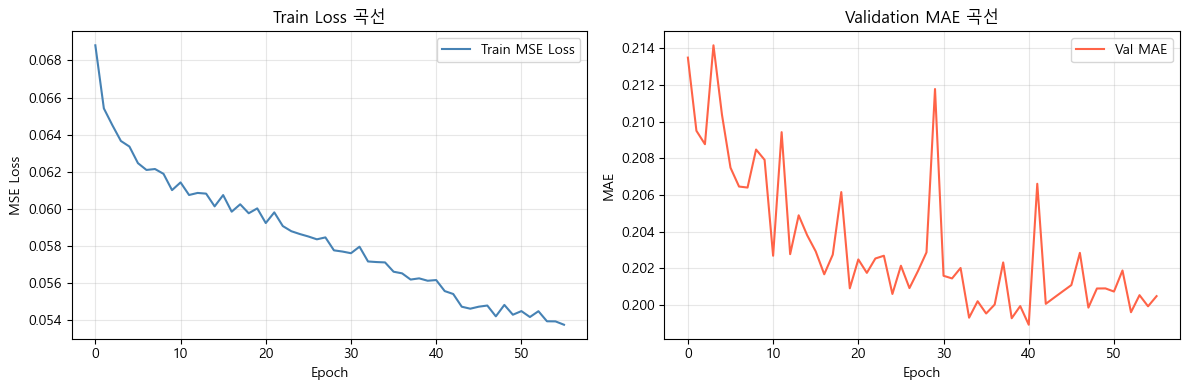

저장: models/training_curves_regression.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train MSE Loss', color='steelblue')
ax1.set_title('Train Loss 곡선')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_maes, label='Val MAE', color='tomato')
ax2.set_title('Validation MAE 곡선')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: models/training_curves_regression.png')

# Step 7: 최종 평가 & 산점도 (예측 vs 실제 VCI)

=== 최종 검증 결과 ===
MAE  (평균절대오차): 0.1989
RMSE (평균제곱근오차): 0.2452
R²   (결정계수):     0.1459

※ NDVI 없이 기상/지형 데이터(Rain, LST, Elevation)만으로 VCI 추론

=== 후처리 분류 결과 (VCI → 건강/주의/위험) ===
               precision    recall  f1-score   support

 건강(VCI≥0.60)       0.65      0.56      0.60       633
주의(0.40~0.60)       0.36      0.68      0.47       379
 위험(VCI<0.40)       0.60      0.03      0.06       275

     accuracy                           0.48      1287
    macro avg       0.54      0.43      0.38      1287
 weighted avg       0.55      0.48      0.45      1287



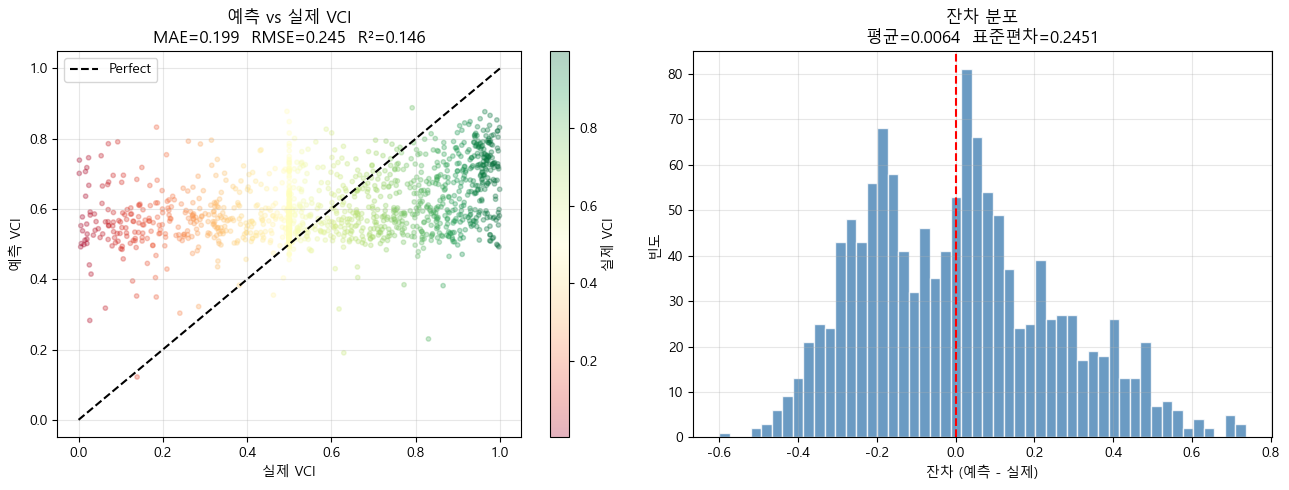

저장: models/regression_eval.png


In [7]:
# 최적 모델 로드
model.load_state_dict(torch.load(MODEL_DIR / 'best_model_regression.pth',
                                  map_location=DEVICE, weights_only=True))
model.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for patch, nums, vci_true in val_loader:
        patch, nums = patch.to(DEVICE), nums.to(DEVICE)
        vci_pred = model(patch, nums).cpu().numpy()
        all_pred.extend(vci_pred)
        all_true.extend(vci_true.numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

mae  = mean_absolute_error(all_true, all_pred)
rmse = np.sqrt(mean_squared_error(all_true, all_pred))
r2   = r2_score(all_true, all_pred)

print('=== 최종 검증 결과 ===')
print(f'MAE  (평균절대오차): {mae:.4f}')
print(f'RMSE (평균제곱근오차): {rmse:.4f}')
print(f'R²   (결정계수):     {r2:.4f}')
print()
print('※ NDVI 없이 기상/지형 데이터(Rain, LST, Elevation)만으로 VCI 추론')

# 후처리: 예측된 VCI → 건강도 분류
def vci_to_label(vci_arr):
    labels = np.where(vci_arr >= 0.60, 0,
             np.where(vci_arr >= 0.40, 1, 2))
    return labels

pred_labels = vci_to_label(all_pred)
true_labels = vci_to_label(all_true)

from sklearn.metrics import classification_report
print('\n=== 후처리 분류 결과 (VCI → 건강/주의/위험) ===')
print(classification_report(true_labels, pred_labels,
                             target_names=['건강(VCI≥0.60)', '주의(0.40~0.60)', '위험(VCI<0.40)']))

# 산점도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 좌: 예측 vs 실제 VCI 산점도
ax = axes[0]
scatter = ax.scatter(all_true, all_pred, alpha=0.3, s=10, c=all_true, cmap='RdYlGn')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect')
ax.set_xlabel('실제 VCI')
ax.set_ylabel('예측 VCI')
ax.set_title(f'예측 vs 실제 VCI\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='실제 VCI')

# 우: 잔차 분포 히스토그램
ax2 = axes[1]
residuals = all_pred - all_true
ax2.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('잔차 (예측 - 실제)')
ax2.set_ylabel('빈도')
ax2.set_title(f'잔차 분포\n평균={residuals.mean():.4f}  표준편차={residuals.std():.4f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'regression_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: models/regression_eval.png')

# Step 8: NDVI 유무 성능 비교 실험

In [8]:
class VegetationDatasetWithNDVI(Dataset):
    """NDVI 포함 버전 (비교용)"""
    NUM_COLS = ['NDVI', 'Rain', 'LST', 'Elevation']

    def __init__(self, df, patch_dir, mean=None, std=None):
        self.patch_dir = Path(patch_dir)
        self.records   = []
        for _, row in df.iterrows():
            period = row['period']
            idx    = int(row['idx'])
            patch_path = self.patch_dir / ('patch_' + str(period) + '_' + str(idx).zfill(4) + '.npy')
            if not patch_path.exists():
                continue
            if 'VCI' not in row or pd.isna(row['VCI']):
                continue
            nums = row[self.NUM_COLS].values.astype(np.float32)
            vci  = float(np.clip(row['VCI'], 0.0, 1.0))
            self.records.append((patch_path, nums, vci))

        all_nums = np.stack([r[1] for r in self.records])
        self.mean = mean if mean is not None else all_nums.mean(0)
        self.std  = std  if std  is not None else all_nums.std(0) + 1e-8

    def __len__(self): return len(self.records)

    def __getitem__(self, i):
        patch_path, nums, vci = self.records[i]
        patch = np.load(patch_path).astype(np.float32)

        # shape 자동 수정
        if patch.ndim == 3 and patch.shape[2] == 7:
            patch = patch.transpose(2, 0, 1)
        patch = patch[:7, :64, :64]
        if patch.shape[1] < 64 or patch.shape[2] < 64:
            pad = np.zeros((7, 64, 64), dtype=np.float32)
            pad[:, :patch.shape[1], :patch.shape[2]] = patch
            patch = pad

        for c in range(patch.shape[0]):
            m, s = patch[c].mean(), patch[c].std() + 1e-8
            patch[c] = (patch[c] - m) / s

        nums = (nums - self.mean) / self.std
        return torch.from_numpy(patch), torch.from_numpy(nums), torch.tensor(vci, dtype=torch.float32)


def train_and_eval(num_numeric, train_df, val_df, epochs=30):
    if num_numeric == 4:
        ds_tr = VegetationDatasetWithNDVI(train_df, PATCH_DIR)
        ds_va = VegetationDatasetWithNDVI(val_df, PATCH_DIR, mean=ds_tr.mean, std=ds_tr.std)
    else:
        ds_tr = VegetationDataset(train_df, PATCH_DIR, augment=True)
        ds_va = VegetationDataset(val_df, PATCH_DIR, augment=False, mean=ds_tr.mean, std=ds_tr.std)

    ld_tr = DataLoader(ds_tr, batch_size=64, shuffle=True,  num_workers=0)
    ld_va = DataLoader(ds_va, batch_size=64, shuffle=False, num_workers=0)

    m = MultimodalFusionRegressor(num_numeric=num_numeric).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)
    crit = nn.MSELoss()

    for ep in range(epochs):
        m.train()
        for patch, nums, vci_true in ld_tr:
            patch, nums, vci_true = patch.to(DEVICE), nums.to(DEVICE), vci_true.to(DEVICE)
            opt.zero_grad()
            loss = crit(m(patch, nums), vci_true)
            loss.backward()
            opt.step()

    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for patch, nums, vci_true in ld_va:
            patch, nums = patch.to(DEVICE), nums.to(DEVICE)
            preds.extend(m(patch, nums).cpu().numpy())
            trues.extend(vci_true.numpy())

    preds, trues = np.array(preds), np.array(trues)
    return {
        'MAE':  mean_absolute_error(trues, preds),
        'RMSE': np.sqrt(mean_squared_error(trues, preds)),
        'R2':   r2_score(trues, preds)
    }


print('=== NDVI 유무 비교 실험 시작 ===')
print('(각 30 epoch 학습, 시간이 다소 걸릴 수 있습니다)')

result_with    = train_and_eval(4, train_df, val_df)
result_without = train_and_eval(3, train_df, val_df)

print('\n=== 비교 결과 ===')
print(f"{'':25s} {'NDVI 포함':>12s} {'NDVI 제거':>12s}")
print('-' * 52)
for metric in ['MAE', 'RMSE', 'R2']:
    print(f"{metric:25s} {result_with[metric]:>12.4f} {result_without[metric]:>12.4f}")
print()
print('※ NDVI 제거 후에도 유사한 성능이 나온다면,')
print('   다중분광 센서 없이도 식생 건강도 예측이 가능함을 의미합니다.')

=== NDVI 유무 비교 실험 시작 ===
(각 30 epoch 학습, 시간이 다소 걸릴 수 있습니다)
유효 샘플 수: 5148
Mean: [  4.1549892  20.02352   238.14763  ]
Std:  [  3.4298549   6.686348  236.64505  ]
유효 샘플 수: 1287
Mean: [  4.1549892  20.02352   238.14763  ]
Std:  [  3.4298549   6.686348  236.64505  ]

=== 비교 결과 ===
                               NDVI 포함      NDVI 제거
----------------------------------------------------
MAE                             0.2057       0.2051
RMSE                            0.2582       0.2503
R2                              0.0523       0.1095

※ NDVI 제거 후에도 유사한 성능이 나온다면,
   다중분광 센서 없이도 식생 건강도 예측이 가능함을 의미합니다.
